# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie
warmte opnemen
$$
Q = mc\Delta T
$$
warmtebron met vast vermogen
$$
Q = Pt
$$
substitutie
$$
c = \frac{Pt}{m\Delta T}
$$

# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.
2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.
```


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.

procedure voor de andere : 
1. bouw de opstelleing
2. stop 400ml water in de maatbeeker
3. voeg te thermometer toe en meet de begin temperatuur
4. zet de mixer aan op ~8  
5. zet het wamte element aan op 30 Wat
6. zet timer aan en meet met de thermometer elke 20 sec de temperatuur
7. doe dit voor minimaal 5 minuten
8. hiernaa kan de opstelling weer worden afgebroken





# Resultaten


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [12]:
#de data voor de andere groep
m_w = 0.150 #kg

U = 15.6 # V
I = 1.59 # A
t = np.arange(0, 5 * 60, 20)
T = np.array([20.8,21.1,21.5,21.9,22.4,22.8,23.1,23.5,23.8,24.1,24.4,24.6,24.9,
              25.2,25.5,25.8,26.1,26.4,26.7,27.0,27.3,27.5,27.9,28.1,28.4,28.7,
              29.0,29.3,29.6,30.0])

In [13]:
#functies voor de diode meting

def func(t, c, T_0):
    #fitten op c en t_0
    #voor t_0 is gekozen omdat het zou kunnen dat de warmte nog niet goed verdeeld was toen het experiment gestart was
    global T, P, m 
    return ((P * t)/(m * c)) + T_0

def fit(t, T):
    #zoekt de beste waardes voor a & b
    popt, pcov = curve_fit(func, t, T, p0=(4186, T[0]))
    a = popt[0]
    b = popt[1]
    u_a = np.sqrt(np.diag(pcov))[0]
    u_b = np.sqrt(np.diag(pcov))[1]
    return a, u_a, b, u_b

4148.598339473149 42.83545146713669 20.555630249419423 0.05215181474317953


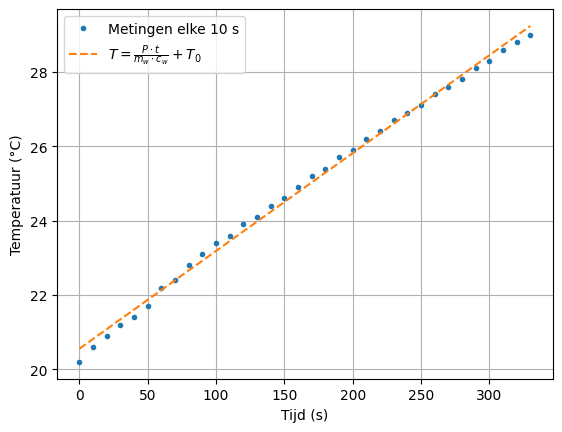

In [14]:
#metingen elke 10 sec
t = np.arange(0, 331, 10)   # 0, 10, 20, ...
T = np.array([20.2, 20.6, 20.9, 21.2, 21.4, 21.7, 22.2, 
              22.4, 22.8, 23.1, 23.4, 23.6, 23.9, 24.1, 24.4, 24.6, 
              24.9, 25.2, 25.4, 25.7, 25.9, 26.2, 26.4, 26.7, 26.9,
              27.1, 27.4, 27.6, 27.8, 28.1, 28.3, 28.6, 28.8, 29.0])

I = 1.56    # stroomsterkte (A)
U = 15.1    # spanning (V)
P = U * I   # vermogen (W)
m = 0.2158  # massa water (kg)

c, u_c, T_0, u_T_0 = fit(t, T)
t_fit = np.linspace(min(t), max(t), 1000)
T_fit = func(t_fit, c, T_0)
print(c, u_c, T_0, u_T_0)


plt.plot(t, T, ".", label='Metingen elke 10 s')
plt.plot(t_fit, T_fit, "--", label=r"$T=\frac{P\cdot t}{m_{w}\cdot c_{w}} + T_{0}$")
plt.xlabel("Tijd (s)")
plt.ylabel("Temperatuur (°C)")
plt.grid()
plt.legend()
plt.savefig("figures/cwater1.png", dpi=450)
plt.show()

# Discussie en conclusie

In [15]:
c_lit = 4186
u_c = np.ceil(u_c/10) * 10
c = np.round(c, -1)
print(f"De warmte capasitiet van water: ({c}±{u_c}) J/kgK")
print(f"literatuur waarde: {c_lit}J/kgK")

De warmte capasitiet van water: (4150.0±50.0) J/kgK
literatuur waarde: 4186J/kgK


zoals te zien is valt de literatuur waarde binnen een keer de onzekerheid
Wat betekend dat de waarde niet streidig is.

Wat bij een vervolg onderzoek beter zou kunnen gaan:
1. onthouden wat voor thermo meter je gebruikt zodat je de onzekerheden in de temperatuur kan berekene
2. heel even wachten met beginnen met meten zodat je niet hebt dat de weerstand nog aan het opwarmen is of dat de mixer het nog niet goed heeft gemixt
